In [ ]:
pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 386.6/386.6 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 231.9/231.9 kB 11.9 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
import xgboost as xgb
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

In [ ]:
df = pd.read_csv('creditcard.csv')
df = df.drop('Time', axis=1)
df.head()


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 30 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   V1      284807 non-null  float64
 1   V2      284807 non-null  float64
 2   V3      284807 non-null  float64
 3   V4      284807 non-null  float64
 4   V5      284807 non-null  float64
 5   V6      284807 non-null  float64
 6   V7      284807 non-null  float64
 7   V8      284807 non-null  float64
 8   V9      284807 non-null  float64
 9   V10     284807 non-null  float64
 10  V11     284807 non-null  float64
 11  V12     284807 non-null  float64
 12  V13     284807 non-null  float64
 13  V14     284807 non-null  float64
 14  V15     284807 non-null  float64
 15  V16     284807 non-null  float64
 16  V17     284807 non-null  float64
 17  V18     284807 non-null  float64
 18  V19     284807 non-null  float64
 19  V20     284807 non-null  float64
 20  V21     284807 non-null  float64
 21  V22     28

Нет пропущенных значений

In [ ]:
df.shape

(284807, 30)

In [ ]:
df = df.drop_duplicates()

In [ ]:
df.shape

(275663, 30)

Text(0.5, 1.0, 'Class Distributions \n (0: No Fraud || 1: Fraud)')

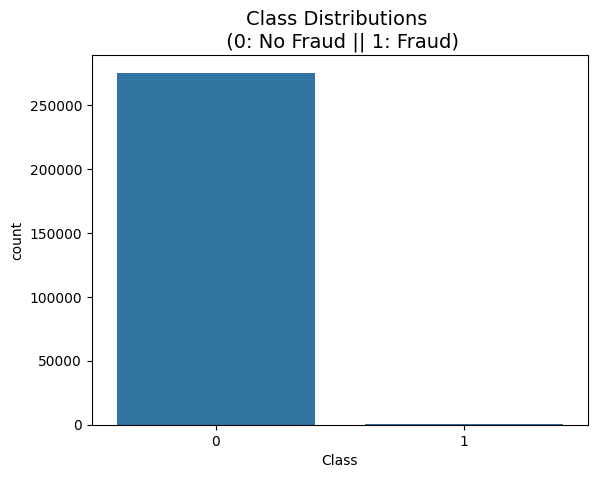

In [ ]:
sns.countplot(x='Class', data=df)
plt.title('Class Distributions \n (0: No Fraud || 1: Fraud)', fontsize=14)

In [ ]:
df.Class.value_counts()


,count
Class,
0,275190
1,473


Датасет несбалансирован

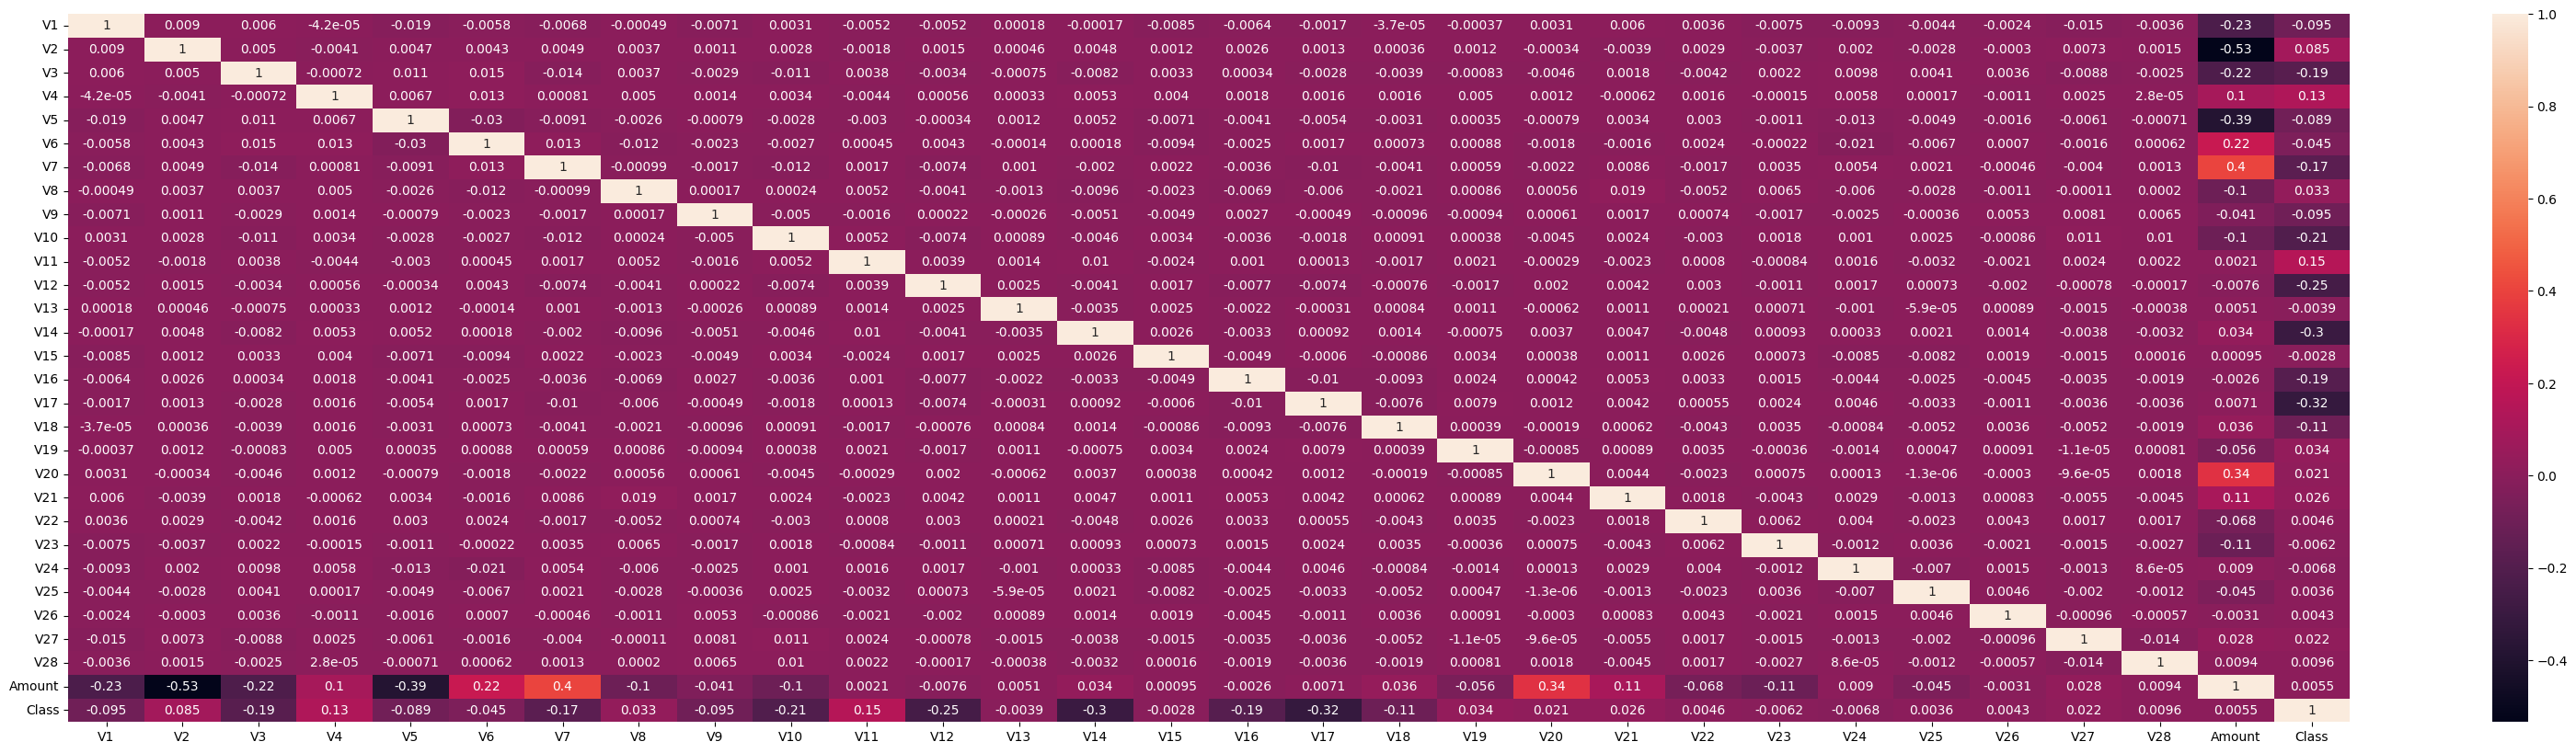

In [ ]:
plt.figure(figsize = (40,10))
sns.heatmap(df.corr(), annot = True)
plt.show()

По матрице корреляции видны признаки мультиколлинеарности, следовательно будем использовать модель градиентного бустинг для реализации модели.

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd
X = df.drop('Class', axis=1)
# Если X — pandas DataFrame
def compute_vif(x):
    vif_data = pd.DataFrame()
    vif_data["feature"] = X.columns
    vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    return vif_data

vif = compute_vif(X)
print(vif.sort_values("VIF", ascending=False))


   feature       VIF
28  Amount  5.540155
1       V2  2.388732
6       V7  1.767623
4       V5  1.727262
19     V20  1.566274
0       V1  1.265972
5       V6  1.211365
2       V3  1.202423
22     V23  1.065771
20     V21  1.055933
7       V8  1.053668
9      V10  1.048716
3       V4  1.047155
21     V22  1.019124
18     V19  1.015468
24     V25  1.012988
8       V9  1.011390
17     V18  1.007111
13     V14  1.006147
26     V27  1.005482
23     V24  1.001151
27     V28  1.000991
11     V12  1.000974
16     V17  1.000843
14     V15  1.000695
15     V16  1.000688
10     V11  1.000332
12     V13  1.000215
25     V26  1.000213


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [17:51:23] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


📊 Confusion Matrix:
[[55015    23]
 [   16    79]]

📋 Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     55038
           1       0.77      0.83      0.80        95

    accuracy                           1.00     55133
   macro avg       0.89      0.92      0.90     55133
weighted avg       1.00      1.00      1.00     55133

🔵 ROC AUC: 0.966052832397138
🟠 PR AUC: 0.8270678063248648


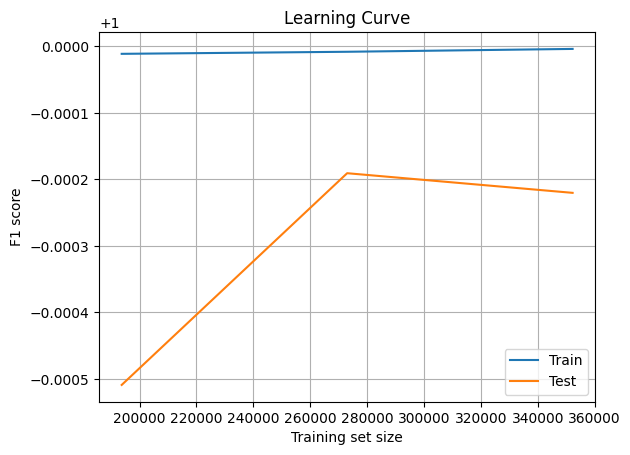

In [ ]:
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, average_precision_score
from imblearn.over_sampling import SMOTE
X = df.drop('Class', axis=1)
y = df['Class']
# 1. Делим на train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# 2. Применяем SMOTE ТОЛЬКО к обучающей выборке
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

model = XGBClassifier(
    max_depth=5,
    n_estimators= 150,
    use_label_encoder=False,
    random_state=42,
    reg_alpha=1,
    reg_lambda=5,
    colsample_bytree=1.0,
)

model.fit(
    X_resampled, y_resampled,
    eval_set=[(X_test, y_test)],
    verbose=False
)
# 4. Предсказания
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

# 5. Метрики
print("📊 Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\n📋 Classification Report:")
print(classification_report(y_test, y_pred))

print("🔵 ROC AUC:", roc_auc_score(y_test, y_proba))
print("🟠 PR AUC:", average_precision_score(y_test, y_proba))


from sklearn.model_selection import learning_curve
import numpy as np

train_sizes, train_scores, test_scores = learning_curve(
    model, X_resampled, y_resampled, cv=5, scoring='f1', n_jobs=-1
)

train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)

plt.plot(train_sizes, train_mean, label="Train")
plt.plot(train_sizes, test_mean, label="Test")
plt.xlabel("Training set size")
plt.ylabel("F1 score")
plt.legend()
plt.grid(True)
plt.title("Learning Curve")
plt.show()

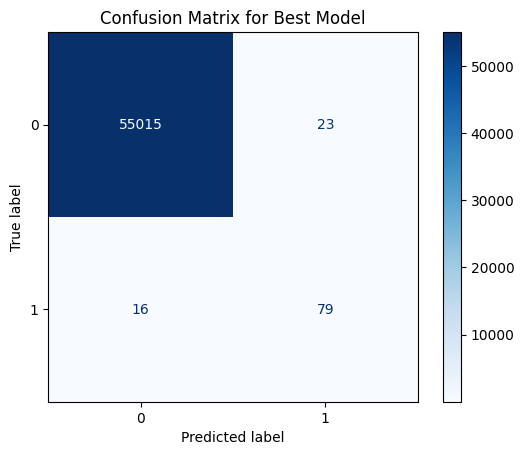

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot(cmap='Blues')
plt.title('Confusion Matrix for Best Model')
plt.show()



Модель демонстрирует в целом хорошее качество, но есть над чем поработать, особенно по «малому» классу:

1. Матрица ошибок  
   - Истинных отрицательных (TN) = 55 015  
   - Ложно‑положительных (FP) = 23  
   - Ложно‑отрицательных (FN) = 16  
   - Истинных положительных (TP) = 79  
   
   Для класса 1 (редкий класс) модель пропустила 16 из 95 случаев (~17 % ошибок пропуска) и выдала 23 ложных сигнала.  

2. Метрики по классам  
   - Класс 0: precision/recall/f1 ≈ 1.00 (за счёт его доминирующей доли)  
   - Класс 1: precision = 0.77, recall = 0.83, F1 = 0.80  
   - Макро‑среднее F1 ≈ 0.90, взвешенное ≈ 1.00  
   
   Важно смотреть именно на метрики класса 1: F1 = 0.80 — неплохо, но для редкой целевой группы можно стремиться выше.  

3. ROC AUC vs PR AUC  
   - ROC AUC ≈ 0.966 говорит о превосходном разделении классов,  
   - но PR AUC = 0.827 более чётко отражает качество на несбалансированном датасете и показывает, что есть запас для роста.  

4. Кривые обучения  
   - Кривые train и test практически совпадают и очень пологие: добавление новых данных почти не меняет F1,  
   - это признак низкой дисперсии (модель не переобучается) и, одновременно, недостаточной сложности (есть незахваченные закономерности).  

In [ ]:
from xgboost import XGBClassifier
import optuna
from sklearn.model_selection import cross_val_score
from sklearn.metrics import make_scorer, f1_score
import numpy as np

def objective(trial):
    params = {
        'max_depth': trial.suggest_int('max_depth', 3, 9),
        'learning_rate': trial.suggest_float('learning_rate', 0.001, 0.1, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 0, 1),
        'reg_lambda': trial.suggest_float('reg_lambda', 0, 1),
        'n_estimators': trial.suggest_categorical('n_estimators', [100, 150, 200, 300])
    }
    model = XGBClassifier(**params, )
    score = cross_val_score(model, X_resampled, y_resampled, cv=5, scoring='f1').mean()
    return score

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50,  show_progress_bar=True)



[I 2025-04-18 13:21:51,463] A new study created in memory with name: no-name-71d7e81f-1f56-4ca1-9a9b-a267449c7033


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2025-04-18 13:23:30,828] Trial 0 finished with value: 0.9867183946426946 and parameters: {'max_depth': 8, 'learning_rate': 0.0014594180662837576, 'subsample': 0.621676318109582, 'reg_alpha': 0.2517601119903994, 'reg_lambda': 0.5440261283052873, 'n_estimators': 200}. Best is trial 0 with value: 0.9867183946426946.
[I 2025-04-18 13:24:46,533] Trial 1 finished with value: 0.9862575654716652 and parameters: {'max_depth': 8, 'learning_rate': 0.0013220112840518605, 'subsample': 0.7073562243295719, 'reg_alpha': 0.06257020657411383, 'reg_lambda': 0.22530942098468765, 'n_estimators': 150}. Best is trial 0 with value: 0.9867183946426946.
[I 2025-04-18 13:25:35,651] Trial 2 finished with value: 0.980550516350401 and parameters: {'max_depth': 7, 'learning_rate': 0.0010569426038340487, 'subsample': 0.6245254312770082, 'reg_alpha': 0.10185788469265122, 'reg_lambda': 0.9994401421848961, 'n_estimators': 100}. Best is trial 0 with value: 0.9867183946426946.
[I 2025-04-18 13:26:45,812] Trial 3 finish

Опишите, что такое optuna и почему он лучше gridsearchcv

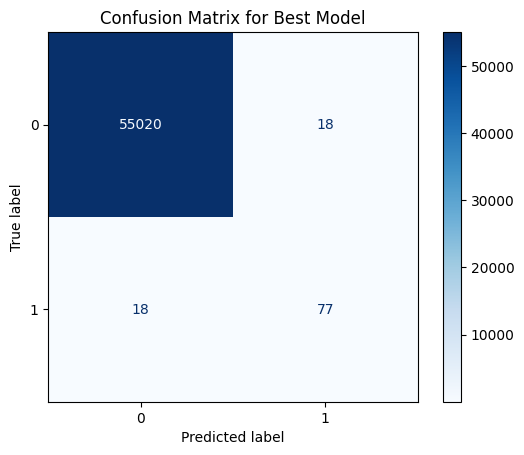

Best parameters: {'max_depth': 9, 'learning_rate': 0.09957582814293757, 'subsample': 0.8007490679244801, 'reg_alpha': 0.70435913397796, 'reg_lambda': 0.08849896941503063, 'n_estimators': 200}
Best F1-score: 0.9998251523206776


In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

best_model = XGBClassifier(**study.best_params, random_state=42)
best_model.fit(X_resampled, y_resampled)

y_pred = best_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred, labels=best_model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_model.classes_)
disp.plot(cmap='Blues')
plt.title('Confusion Matrix for Best Model')
plt.show()

# 5. Вывод лучших параметров
print("Best parameters:", study.best_params)
print("Best F1-score:", study.best_value)

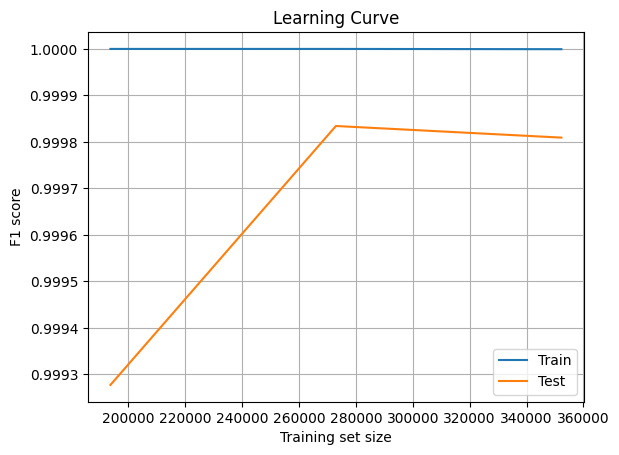

In [ ]:
from sklearn.model_selection import learning_curve
import numpy as np

train_sizes, train_scores, test_scores = learning_curve(
    best_model, X_resampled, y_resampled, cv=5, scoring='f1', n_jobs=-1
)

train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)

plt.plot(train_sizes, train_mean, label="Train")
plt.plot(train_sizes, test_mean, label="Test")
plt.xlabel("Training set size")
plt.ylabel("F1 score")
plt.legend()
plt.grid(True)
plt.title("Learning Curve")
plt.show()


Возможно есть переобучение

In [ ]:
print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     55038
           1       0.81      0.81      0.81        95

    accuracy                           1.00     55133
   macro avg       0.91      0.91      0.91     55133
weighted avg       1.00      1.00      1.00     55133



In [ ]:
from sklearn.metrics import accuracy_score

train_pred = best_model.predict(X_resampled)
test_pred = best_model.predict(X_test)

print("Train Accuracy:", accuracy_score(y_resampled, train_pred))
print("Test Accuracy:", accuracy_score(y_test, test_pred))

Train Accuracy: 1.0
Test Accuracy: 0.9993470335370831


 Если train_accuracy намного выше, чем test_accuracy, то это признак переобучения.

Крч полученная модель обладает признаками переобучения, возможно лучше юзать предыдущую и тд

Да, на представленных результатах наблюдаются признаки переобучения, хотя модель демонстрирует высокую точность как на обучающей, так и на тестовой выборке. Рассмотрим подробнее:

📌 1. Метрики на обучающей и тестовой выборках:
python
Копировать
Редактировать
Train Accuracy: 1.0
Val Accuracy: 0.9993470335370831
Train Accuracy = 1.0 — абсолютная точность на обучающей выборке.

Validation Accuracy ≈ 0.9993 — очень высокая точность, но чуть ниже, чем на обучении.

👉 Это может быть признаком переобучения, особенно если модель слишком "запомнила" обучающие данные.

📌 2. Кривая обучения (learning curve):
Линия обучения (Train) на уровне F1 ≈ 1.0 и не изменяется при увеличении объёма обучающей выборки — это сигнал, что модель идеально подогнана под обучение.

Линия теста (Test) растёт до определённого момента, затем слегка снижается — что также может указывать на недостаточную обобщающую способность модели при росте объёма данных.

📌 3. Classification Report:

Класс  Precision  Recall  F1-score  Support
0  1.00  1.00  1.00  55038
1  0.81  0.81  0.81  95
Модель хорошо предсказывает основной класс (0), но по миноритарному классу (1) уже заметно падение метрик (precision, recall, f1 ≈ 0.81).

Это ещё один косвенный признак переобучения на большинство, особенно если был дисбаланс классов.

💡 Вывод:
Признаки переобучения присутствуют, особенно:

Идеальная точность на обучении.

Незначительное снижение точности и F1 на валидации.

Сильная диспропорция между классами (majority/minority).

Низкая обобщающая способность на редкие классы.


крч укажите обязательно, что вторая модель скорее всего переобучается
и причины (тип дисбаланс классов и  тд)